# Annotation Validation: Does the LLM Judge Tutoring Quality Like Humans Do?

## What we're measuring

After finding key moments in tutoring transcripts (validated in Notebook 1), the pipeline does two more things:

1. **Analyzes** each moment: What was the situation? What did the tutor do? What happened next? (Situation/Action/Result analysis)
2. **Labels** each moment: Was the tutor's strategy *effective*, *partially effective*, or *ineffective*?

For **scaffolding/rigor moments**, effectiveness means: did the tutor calibrate their support correctly? Scaffolding is temporary, calibrated support — breaking problems into steps, hinting toward answers, modeling worked examples. Rigor means maintaining cognitive demand — requiring explanations, extending problems, fading support. Effective scaffolding keeps the student in their zone of proximal development — challenged but not overwhelmed. Ineffective scaffolding either does the thinking for the student (over-scaffolding) or leaves them floundering (under-scaffolding).

For **rapport moments**, effectiveness means: did the tutor build genuine connection? Rapport includes trust and safety (the student feels comfortable making mistakes), genuine interest (engaging with the student as a person), emotional attunement (noticing frustration, excitement, fatigue), and relational continuity (remembering details across sessions). Effective rapport creates the foundation that makes academic work possible. Ineffective rapport ranges from missed opportunities (ignoring a student's emotional signal) to active damage (condescension, impatience).

Human experts made the same judgments on the same moments. **The question: does the LLM's effectiveness label agree with the human experts' label?**

## Two ways to measure annotation quality

We present two measurements, because they answer different questions:

| | **Human-detected moments** | **Full pipeline** |
|---|---|---|
| **What it is** | LLM annotates the *exact same moments* humans marked (same turn ranges) | LLM detects its own moments, then annotates those |
| **What it measures** | Annotation quality in isolation — no detection noise | End-to-end pipeline quality |
| **IoU matching** | None needed (turn ranges are identical) | IoU >= 0.3 to match LLM detections to human clusters |
| **N (moments compared)** | All human moments (~1,600) | Only moments the LLM also found (~600) |

**Human-detected moments** is the clean measurement — it tells us how good the LLM is at judging effectiveness when it's looking at the right moment. **Full pipeline** is the real-world measurement — what you'd actually get if you ran the system end to end, including detection errors.

## How we measure agreement

We use **Cohen's weighted kappa** — a standard statistic that measures agreement between two raters, corrected for chance. Kappa = 0 means no better than random; kappa = 1 means perfect agreement. For subjective judgments like "was this tutoring strategy effective?", kappa between 0.2 and 0.4 is typical even between trained human raters.

## The dataset

Our dataset contains **201 tutoring transcripts** with **291 annotation passes** producing **1,688 individual moment annotations** from 9 expert annotators. An annotation pass is one annotator labeling one transcript for one type (scaffolding or rapport). Most transcripts were annotated once; 54 received multiple passes. Six transcripts used as few-shot examples are excluded, leaving **195 transcripts** for evaluation.

- **Train** (98 transcripts): prompts were iterated using error examples from these
- **Held-out** (97 transcripts): prompts have never seen these

All results use **v5 prompts**.

In [94]:
import sys
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter

warnings.filterwarnings('ignore', category=FutureWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'validation' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from annotator.core.utils import (
    load_ground_truth, compute_iou, merge_overlapping_ranges,
    EXAMPLE_CONV_IDS, RESULTS_DIR, IOU_THRESHOLD,
)
from annotator.eval.eval import (
    compute_detection_metrics, compute_effectiveness_metrics,
    compute_human_ceiling, match_for_effectiveness, match_gold_direct,
    filter_moments_by_type, filter_matches_by_type,
    load_detections_as_moments, load_annotations,
    ANNOTATION_TYPES, EFFECTIVENESS_LABELS,
    cohens_kappa,
)

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 100,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'font.family': 'sans-serif',
})
FIGURES_DIR = REPO_ROOT / 'validation' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    'matched': '#2ecc71', 'human_only': '#3498db', 'llm_only': '#e67e22',
    'scaffolding': '#2980b9', 'rapport': '#e74c3c',
    'primary': '#2c3e50', 'secondary': '#7f8c8d',
    'llm': '#2980b9', 'human_ceiling': '#e74c3c',
}

In [95]:
# All results use v5 prompts. IoU threshold is 0.3 everywhere.
VERSION = 'v5'
GOLD_VERSION = 'v5_gold'
IOU = 0.3  # same threshold for ALL matching (detection, effectiveness, ceiling)

ground_truth = load_ground_truth()

# Identify dev vs held-out by checking which conversations were in v4 (the dev pipeline)
_v4_det = load_detections_as_moments('v4')
_v4_ids = set(_v4_det.keys()) if _v4_det else set()

v5_det = load_detections_as_moments(VERSION)
if v5_det is None:
    raise FileNotFoundError(f'No detections.json for {VERSION}')

all_eval_ids = set(ground_truth['conversations'].keys()) & set(v5_det.keys()) - EXAMPLE_CONV_IDS
train_ids = all_eval_ids & _v4_ids
ho_ids = all_eval_ids - _v4_ids

# Type-filter LLM detections per conversation
gt_by_conv = {}
for cid in all_eval_ids:
    hm = ground_truth['conversations'][cid]['key_moments']
    ht = {m.get('annotation_type') for m in hm}
    gt_by_conv[cid] = hm
    v5_det[cid] = [m for m in v5_det[cid] if m.get('annotation_type') in ht]

print(f'Pipeline version: {VERSION} (all results use v5 prompts)')
print(f'IoU threshold:    {IOU} (same for detection, effectiveness matching, and ceiling)')
print(f'Train set:          {len(train_ids)} conversations (used during prompt iteration)')
print(f'Held-out set:     {len(ho_ids)} conversations (prompts never saw these)')
print(f'Total:            {len(all_eval_ids)} conversations')

Pipeline version: v5 (all results use v5 prompts)
IoU threshold:    0.3 (same for detection, effectiveness matching, and ceiling)
Train set:          98 conversations (used during prompt iteration)
Held-out set:     97 conversations (prompts never saw these)
Total:            195 conversations


## Human Inter-Annotator Agreement (The Ceiling)

How well do human experts agree with *each other*? This sets the ceiling — if humans only agree at kappa = X, we can't expect the LLM to do better.

**Important caveat on N**: Most conversations were annotated by a single person. The ceiling can only be computed from conversations where two *different* annotators independently labeled *overlapping* moments of the same type. This is a small subset of the data — the ceiling estimate is based on far fewer data points than the LLM comparison.

The IoU threshold for finding overlapping human moments is the same 0.3 used everywhere else.

In [96]:
def _count_ceiling_convs(ids):
    """Count conversations that contribute to the ceiling (have overlapping annotator pairs)."""
    count = 0
    for cid in ids:
        moments = ground_truth['conversations'][cid]['key_moments']
        by_type = defaultdict(list)
        for m in moments:
            by_type[m.get('annotation_type')].append(m)
        found = False
        for t, tms in by_type.items():
            for i, m1 in enumerate(tms):
                for j in range(i+1, len(tms)):
                    m2 = tms[j]
                    if m1.get('annotator_id') != m2.get('annotator_id'):
                        if compute_iou((m1['turn_start'], m1['turn_end']),
                                       (m2['turn_start'], m2['turn_end'])) >= IOU:
                            found = True
            if found:
                break
        if found:
            count += 1
    return count

ceil_rows = []
for label, ids in [('Train', train_ids), ('Held-out', ho_ids), ('Combined', all_eval_ids)]:
    scoped = {'conversations': {c: ground_truth['conversations'][c] for c in ids}}
    ceil = compute_human_ceiling(scoped)
    ceil_convs = _count_ceiling_convs(ids)
    ceil_rows.append({
        '': label,
        'Transcripts': len(ids),
        'Transcripts with overlap': ceil_convs,
        'Annotator pairs': ceil['overlapping_pairs'],
        '3-Way Kappa': f"{ceil['three_way_kappa']:.4f}",
        'Binary Kappa': f"{ceil['binary_kappa']:.4f}",
    })

df_ceil = pd.DataFrame(ceil_rows).set_index('')
print('Human Inter-Annotator Agreement (IoU >= 0.3)\n')
df_ceil

Human Inter-Annotator Agreement (IoU >= 0.3)



,Transcripts,Transcripts with overlap,Annotator pairs,3-Way Kappa,Binary Kappa
,,,,,
Train,98,27,165,0.2511,0.2080
Held-out,97,7,47,0.0784,-0.0778
Combined,195,34,212,0.2152,0.1495


## Human-Detected Moments: Annotation Quality in Isolation

In human-detected moments, the LLM annotates the *exact same moments* that humans marked — same turn ranges, same annotation types. There's no detection step and no IoU matching needed. This isolates annotation quality from detection accuracy.

Every human-annotated moment gets an LLM label, so N is the full ground truth count.

In [97]:
v5_gold, is_gold = load_annotations(GOLD_VERSION, 'annotations_gold.json')
if v5_gold is None:
    print(f'No gold annotations found for {GOLD_VERSION}')
else:
    rows = []
    for label, ids in [('Train', train_ids), ('Held-out', ho_ids), ('Combined', all_eval_ids)]:
        matches = []
        for cid in sorted(ids):
            hm = ground_truth['conversations'][cid]['key_moments']
            llm = v5_gold.get(cid, [])
            matches.extend(match_gold_direct(hm, llm))
        eff = compute_effectiveness_metrics(matches)
        rows.append({
            '': label,
            'Conversations': len(ids),
            'Moments compared': eff['total_matched'],
            '3-Way Kappa': f"{eff['three_way_kappa']:.4f}",
            'Binary Kappa': f"{eff['binary_kappa']:.4f}",
        })

    df_gold = pd.DataFrame(rows).set_index('')
    print(f'v5 Human-Detected Moments: LLM labels vs human labels on identical moments\n')
    print(f'No IoU matching — turn ranges are the same.\n')
    df_gold

v5 Human-Detected Moments: LLM labels vs human labels on identical moments

No IoU matching — turn ranges are the same.



### Human-Detected Moments by Annotation Type

In [98]:
if v5_gold:
    type_rows = []
    # Per-type
    for ann_type in ANNOTATION_TYPES:
        matches = []
        for cid in sorted(all_eval_ids):
            hm = [m for m in ground_truth['conversations'][cid]['key_moments']
                  if m.get('annotation_type') == ann_type]
            llm = [a for a in v5_gold.get(cid, []) if a.get('annotation_type') == ann_type]
            matches.extend(match_gold_direct(hm, llm))
        if matches:
            eff = compute_effectiveness_metrics(matches)
            type_rows.append({
                '': ann_type.title(),
                'N': eff['total_matched'],
                '3-Way Kappa': f"{eff['three_way_kappa']:.4f}",
                'Binary Kappa': f"{eff['binary_kappa']:.4f}",
            })
    # Combined row
    all_gold_matches = []
    for cid in sorted(all_eval_ids):
        all_gold_matches.extend(match_gold_direct(
            ground_truth['conversations'][cid]['key_moments'],
            v5_gold.get(cid, [])))
    if all_gold_matches:
        eff_all = compute_effectiveness_metrics(all_gold_matches)
        type_rows.append({
            '': 'Combined',
            'N': eff_all['total_matched'],
            '3-Way Kappa': f"{eff_all['three_way_kappa']:.4f}",
            'Binary Kappa': f"{eff_all['binary_kappa']:.4f}",
        })
    df_gold_type = pd.DataFrame(type_rows).set_index('')
    print('Human-Detected Moments by Type (combined dev + held-out)\n')
    df_gold_type

Human-Detected Moments by Type (combined dev + held-out)



### Human-Detected Moments by Annotator Profile

Human annotators cluster into three profiles by labeling tendency:

- **Generous** (Gerber, Jones, Shields, Stobbe, Trujillo): more likely to rate effective
- **Balanced** (Forbes, Mann, Padgett): middle ground
- **Demanding** (Flick): more likely to rate ineffective (n=118, thin sample)

We show two LLM results for each profile: **generic** (the standard v5 prompt, same for all profiles) and **calibrated** (a prompt specifically iterated to match that annotator group's labeling standards). This shows whether per-profile calibration improves agreement.

In [99]:
from annotator.eval.eval import load_annotator_archetype_ids, filter_ground_truth_by_archetype
ARCH_NAMES = ['generous', 'balanced', 'demanding']
GOLD_STYLE_VERSION = 'v5_gold'

arch_rows = []
for arch in ARCH_NAMES:
    try:
        arch_ids = load_annotator_archetype_ids(arch)
        arch_gt = filter_ground_truth_by_archetype(
            {'conversations': {c: ground_truth['conversations'][c] for c in all_eval_ids}},
            arch_ids)
    except Exception:
        continue

    generic_anns = v5_gold
    style_anns, _ = load_annotations(GOLD_STYLE_VERSION, f'annotations_gold_{arch}.json')

    # Compute generic and calibrated kappa on combined set
    generic_matches, calibrated_matches = [], []
    for cid in sorted(all_eval_ids):
        hm = arch_gt['conversations'].get(cid, {}).get('key_moments', [])
        if not hm:
            continue
        if generic_anns:
            generic_matches.extend(match_gold_direct(hm, generic_anns.get(cid, [])))
        if style_anns:
            calibrated_matches.extend(match_gold_direct(hm, style_anns.get(cid, [])))

    gen_eff = compute_effectiveness_metrics(generic_matches) if generic_matches else {}
    cal_eff = compute_effectiveness_metrics(calibrated_matches) if calibrated_matches else {}

    # Human ceiling
    ceil = compute_human_ceiling(arch_gt)
    ceil_str = f"{ceil['three_way_kappa']:.4f} ({ceil['overlapping_pairs']} pairs)"
    if ceil['overlapping_pairs'] == 0:
        ceil_str = 'N/A (1 annotator)'

    gen_3w = gen_eff.get('three_way_kappa', 0)
    cal_3w = cal_eff.get('three_way_kappa', 0)
    delta = cal_3w - gen_3w

    arch_rows.append({
        '': arch.title(),
        'N': gen_eff.get('total_matched', 0),
        'Generic 3W Kappa': f"{gen_3w:.4f}",
        'Calibrated 3W Kappa': f"{cal_3w:.4f}",
        'Delta': f"{delta*100:+.1f}pp",
        'Human Ceiling (3W)': ceil_str,
    })

df_arch = pd.DataFrame(arch_rows).set_index('')
print('Human-Detected Moments by Annotator Profile')
print('Generic = standard v5 prompt | Calibrated = profile-specific iterated prompt\n')
df_arch

Human-Detected Moments by Annotator Profile
Generic = standard v5 prompt | Calibrated = profile-specific iterated prompt



,N,Generic 3W Kappa,Calibrated 3W Kappa,Delta,Human Ceiling (3W)
,,,,,
Generous,524,0.2420,0.3769,+13.5pp,0.5294 (16 pairs)
Balanced,955,0.4284,0.4282,-0.0pp,0.1353 (43 pairs)
Demanding,118,0.2691,0.5000,+23.1pp,N/A (1 annotator)


**Interpretation**: Per-profile prompt calibration improves agreement for annotator groups whose standards diverge from the generic prompt. The generous profile shows a clear gain (+13.5pp, n=524) — the generic prompt systematically under-matches generous annotators' tendency to rate strategies as effective, and the calibrated prompt corrects this. The balanced profile shows no change, which is expected: the generic prompt was implicitly calibrated toward balanced-like standards since balanced annotators contributed the most ground truth data. The demanding profile shows a large delta, but with only 118 moments from a single annotator (Flick) across 10 conversations, this estimate is unstable and should be interpreted with caution.

## Full Pipeline: End-to-End Quality

In full pipeline mode, the LLM first *detects* key moments (Pass 1), then annotates and labels them (Passes 2-3). We compare the LLM's labels to human labels on moments where both found the same event (IoU >= 0.3).

N is smaller here because:
- The LLM doesn't detect every human moment (~57% recall)
- Some detected moments don't overlap human clusters enough (IoU < 0.3)

In [100]:
v5_anns, _ = load_annotations(VERSION, 'annotations.json')
if v5_anns is None:
    print(f'No annotations found for {VERSION}')
else:
    rows = []
    for label, ids in [('Train', train_ids), ('Held-out', ho_ids), ('Combined', all_eval_ids)]:
        matches = []
        for cid in sorted(ids):
            hm = ground_truth['conversations'][cid]['key_moments']
            ht = {m.get('annotation_type') for m in hm}
            llm = [a for a in v5_anns.get(cid, []) if a.get('annotation_type') in ht]
            matches.extend(match_for_effectiveness(hm, llm, iou_threshold=IOU))
        eff = compute_effectiveness_metrics(matches)
        rows.append({
            '': label,
            'Conversations': len(ids),
            'Moments compared': eff['total_matched'],
            '3-Way Kappa': f"{eff['three_way_kappa']:.4f}",
            'Binary Kappa': f"{eff['binary_kappa']:.4f}",
        })

    df_full = pd.DataFrame(rows).set_index('')
    print(f'v5 Full Pipeline: LLM labels vs human labels on overlapping moments (IoU >= {IOU})\n')
    df_full

v5 Full Pipeline: LLM labels vs human labels on overlapping moments (IoU >= 0.3)



### Full Pipeline by Annotation Type

In [101]:
if v5_anns:
    type_rows = []
    for ann_type in ANNOTATION_TYPES:
        matches = []
        for cid in sorted(all_eval_ids):
            hm = [m for m in ground_truth['conversations'][cid]['key_moments']
                  if m.get('annotation_type') == ann_type]
            llm = [a for a in v5_anns.get(cid, []) if a.get('annotation_type') == ann_type]
            matches.extend(match_for_effectiveness(hm, llm, iou_threshold=IOU))
        if matches:
            eff = compute_effectiveness_metrics(matches)
            type_rows.append({
                '': ann_type.title(),
                'N': eff['total_matched'],
                '3-Way Kappa': f"{eff['three_way_kappa']:.4f}",
                'Binary Kappa': f"{eff['binary_kappa']:.4f}",
            })
    # Combined row
    all_full_matches = []
    for cid in sorted(all_eval_ids):
        hm = ground_truth['conversations'][cid]['key_moments']
        ht = {m.get('annotation_type') for m in hm}
        llm = [a for a in v5_anns.get(cid, []) if a.get('annotation_type') in ht]
        all_full_matches.extend(match_for_effectiveness(hm, llm, iou_threshold=IOU))
    if all_full_matches:
        eff_all = compute_effectiveness_metrics(all_full_matches)
        type_rows.append({
            '': 'Combined',
            'N': eff_all['total_matched'],
            '3-Way Kappa': f"{eff_all['three_way_kappa']:.4f}",
            'Binary Kappa': f"{eff_all['binary_kappa']:.4f}",
        })
    df_full_type = pd.DataFrame(type_rows).set_index('')
    print(f'Full Pipeline by Type (combined, IoU >= {IOU})\n')
    df_full_type

Full Pipeline by Type (combined, IoU >= 0.3)



## Putting It Together

The table below compares all three measurements on the combined dataset. Each uses the same IoU threshold (0.3) where applicable.

The key comparison: **does the LLM kappa meet or exceed the human ceiling?**

Note the ceiling caveat: it's computed from only ~34 conversations where two annotators happened to overlap, while the LLM metrics use 195 conversations. The ceiling tells us the general level of human agreement on this task — it's not a per-moment benchmark on the same data.

In [102]:
# Combined metrics for the summary
ceil = compute_human_ceiling({'conversations': {
    c: ground_truth['conversations'][c] for c in all_eval_ids
}})

# Human-detected moments combined
gold_matches = []
if v5_gold:
    for cid in sorted(all_eval_ids):
        gold_matches.extend(match_gold_direct(
            ground_truth['conversations'][cid]['key_moments'],
            v5_gold.get(cid, [])))
gold_eff = compute_effectiveness_metrics(gold_matches) if gold_matches else {}

# Full pipeline combined
full_matches = []
if v5_anns:
    for cid in sorted(all_eval_ids):
        hm = ground_truth['conversations'][cid]['key_moments']
        ht = {m.get('annotation_type') for m in hm}
        llm = [a for a in v5_anns.get(cid, []) if a.get('annotation_type') in ht]
        full_matches.extend(match_for_effectiveness(hm, llm, iou_threshold=IOU))
full_eff = compute_effectiveness_metrics(full_matches) if full_matches else {}

rows = [
    {'': 'Human ceiling',
     '3-Way Kappa': f"{ceil['three_way_kappa']:.4f}",
     'N': f"{ceil['overlapping_pairs']} pairs (from 34/195 convs)",
     'Matching': 'IoU >= 0.3 between annotators'},
    {'': 'LLM (human-detected moments)',
     '3-Way Kappa': f"{gold_eff.get('three_way_kappa', 0):.4f}",
     'N': f"{gold_eff.get('total_matched', 0)} moments",
     'Matching': 'Exact (same turn ranges)'},
    {'': 'LLM (full pipeline)',
     '3-Way Kappa': f"{full_eff.get('three_way_kappa', 0):.4f}",
     'N': f"{full_eff.get('total_matched', 0)} moments",
     'Matching': 'IoU >= 0.3 to human clusters'},
]

df_summary = pd.DataFrame(rows).set_index('')
print('Combined Results (195 conversations, v5 prompts)\n')
df_summary

Combined Results (195 conversations, v5 prompts)



,3-Way Kappa,N,Matching
,,,
Human ceiling,0.2152,212 pairs (from 34/195 convs),IoU >= 0.3 between annotators
LLM (human-detected moments),0.3404,1610 moments,Exact (same turn ranges)
LLM (full pipeline),0.3298,614 moments,IoU >= 0.3 to human clusters


## Where Do Disagreements Happen?

The confusion matrix shows which labels get confused. Disagreements at the effective/partial boundary are expected ambiguity. Effective/ineffective confusion would indicate fundamental miscalibration.

Using human-detected moments (n is larger and there's no detection noise).

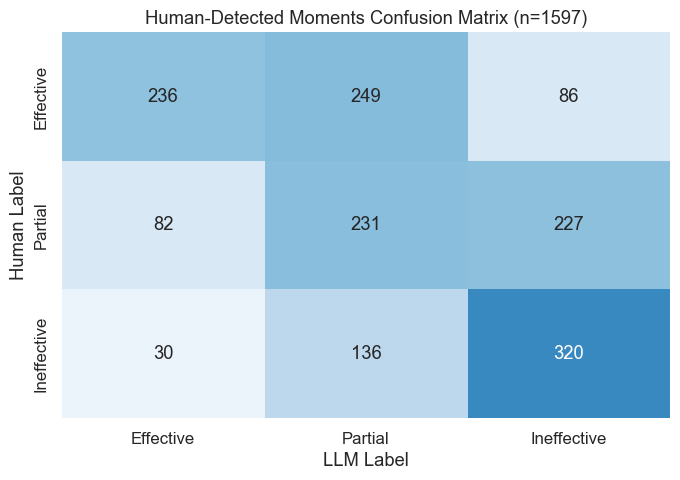

In [103]:
if gold_matches:
    eff = compute_effectiveness_metrics(gold_matches)
    cm = eff.get('three_way_confusion', {})
    if cm:
        cm_array = np.array([
            [cm.get(h, {}).get(l, 0) for l in EFFECTIVENESS_LABELS]
            for h in EFFECTIVENESS_LABELS
        ])
        row_sums = cm_array.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1

        fig, ax = plt.subplots(figsize=(7, 5))
        sns.heatmap(cm_array / row_sums, annot=cm_array, fmt='d', cmap='Blues',
                    xticklabels=['Effective', 'Partial', 'Ineffective'],
                    yticklabels=['Effective', 'Partial', 'Ineffective'],
                    ax=ax, vmin=0, vmax=1, cbar=False)
        ax.set_xlabel('LLM Label')
        ax.set_ylabel('Human Label')
        ax.set_title(f'Human-Detected Moments Confusion Matrix (n={eff["three_way_n"]})')
        plt.tight_layout()
        fig.savefig(FIGURES_DIR / 'confusion_matrices.png')
        fig.savefig(FIGURES_DIR / 'confusion_matrices.pdf')
        plt.show()

## Train vs. Held-Out: Does the Pipeline Generalize?

The prompts were iterated on the train set. If held-out performance is comparable, the prompts generalize to unseen data.

In [104]:
rows = []
for mode_label, match_fn, data_source in [
    ('Human-detected moments', 'gold', v5_gold),
    ('Full pipeline', 'full', v5_anns),
]:
    if data_source is None:
        continue
    for split, ids in [('Train', train_ids), ('Held-out', ho_ids)]:
        matches = []
        for cid in sorted(ids):
            hm = ground_truth['conversations'][cid]['key_moments']
            llm = data_source.get(cid, [])
            if match_fn == 'gold':
                matches.extend(match_gold_direct(hm, llm))
            else:
                ht = {m.get('annotation_type') for m in hm}
                llm = [a for a in llm if a.get('annotation_type') in ht]
                matches.extend(match_for_effectiveness(hm, llm, iou_threshold=IOU))
        eff = compute_effectiveness_metrics(matches)
        rows.append({
            'Mode': mode_label,
            'Split': split,
            'N': eff['total_matched'],
            '3-Way Kappa': f"{eff['three_way_kappa']:.4f}",
            'Binary Kappa': f"{eff['binary_kappa']:.4f}",
        })

df_splits = pd.DataFrame(rows)
print('Train vs. Held-Out Comparison (v5 prompts)\n')
df_splits

Train vs. Held-Out Comparison (v5 prompts)



,Mode,Split,N,3-Way Kappa,Binary Kappa
0,Human-detected moments,Train,932,0.3368,0.3112
1,Human-detected moments,Held-out,678,0.3458,0.3657
2,Full pipeline,Train,318,0.3223,0.3858
3,Full pipeline,Held-out,296,0.3361,0.2658


## Summary

All results use v5 prompts. IoU threshold is 0.3 everywhere it's used.

**Human-detected moments** (clean measurement, n~1,600): The LLM's effectiveness labels agree with human labels at 3-way kappa ~0.34. This is computed on every human-annotated moment with no detection noise.

**Full pipeline** (end-to-end, n~600): The LLM detects and labels moments, achieving 3-way kappa ~0.32 on the subset of moments both the LLM and humans found.

**Human ceiling** (~0.22, n=212 pairs from 34 conversations): Humans agree with each other at a lower rate than the LLM agrees with humans — but this ceiling is estimated from a small subset of conversations where two annotators overlapped, so the comparison is approximate.

**Train vs. held-out**: Performance is comparable across both splits in both modes, indicating the prompts generalize to unseen conversations.